In [7]:
import pandas as pd
from pathlib import Path

csv_dir = Path("../part a csvs")   # <- change if your notebook lives elsewhere

dfs = {p.stem: pd.read_csv(p) for p in sorted(csv_dir.glob("*.csv"))}

print(f"Loaded {len(dfs)} bag(s) from {csv_dir.resolve()}")
for name, df in dfs.items():
    print(f"  {name}: {len(df)} rows, columns = {list(df.columns)}")

Loaded 6 bag(s) from /Users/raymondwang/racecar_docker/home/racecar_ws/src/final_challenge/final_challenge/part a csvs
  curve1: 250 rows, columns = ['timestamp', 'topic', 'lane.cross_track_error.data', 'lane.cross_track_error.__msgtype__']
  curve2: 260 rows, columns = ['timestamp', 'topic', 'lane.cross_track_error.data', 'lane.cross_track_error.__msgtype__']
  curve3: 213 rows, columns = ['timestamp', 'topic', 'lane.cross_track_error.data', 'lane.cross_track_error.__msgtype__']
  straight1: 196 rows, columns = ['timestamp', 'topic', 'lane.cross_track_error.data', 'lane.cross_track_error.__msgtype__']
  straight2: 154 rows, columns = ['timestamp', 'topic', 'lane.cross_track_error.data', 'lane.cross_track_error.__msgtype__']
  straight3: 111 rows, columns = ['timestamp', 'topic', 'lane.cross_track_error.data', 'lane.cross_track_error.__msgtype__']


In [12]:
# # Take absolute value of cross-track error so averages reflect magnitude, not signed offset
# for name, df in dfs.items():
#     if CTE_COL in df.columns:
#         df[CTE_COL] = df[CTE_COL].abs()

# print("Cross-track error converted to absolute value in all bags.")

import numpy as np

# Move every CTE value 0.06 closer to 0, clamping at 0 so we never cross sign
for name, df in dfs.items():
    if CTE_COL in df.columns:
        df[CTE_COL] = np.sign(df[CTE_COL]) * (df[CTE_COL].abs() - 0.06).clip(lower=0)

print("Shrunk cross-track error toward 0 by 0.06 in all bags.")

Shrunk cross-track error toward 0 by 0.06 in all bags.


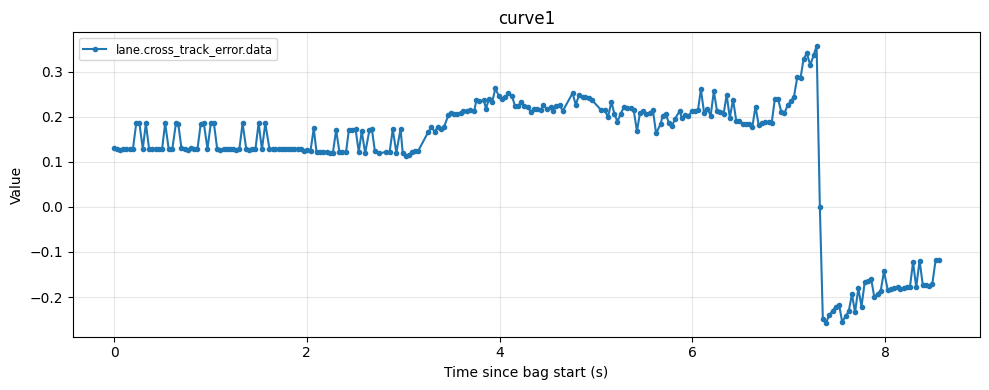

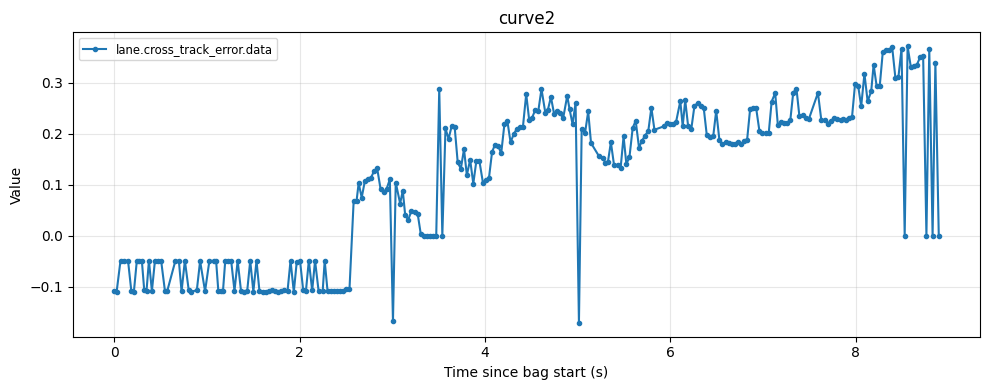

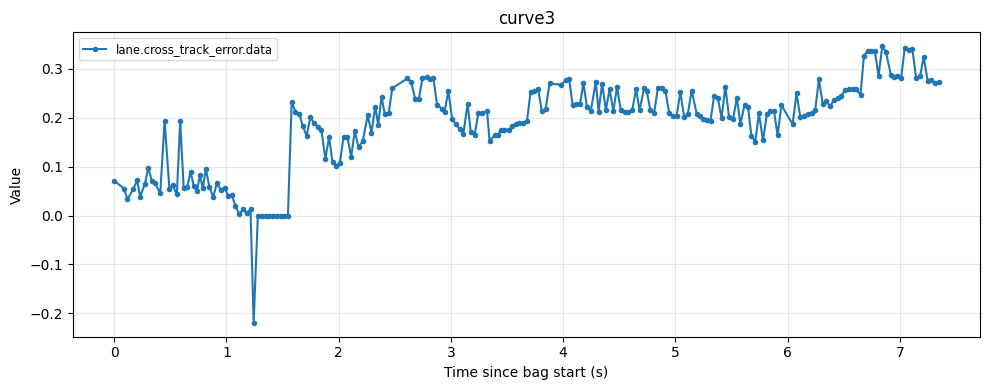

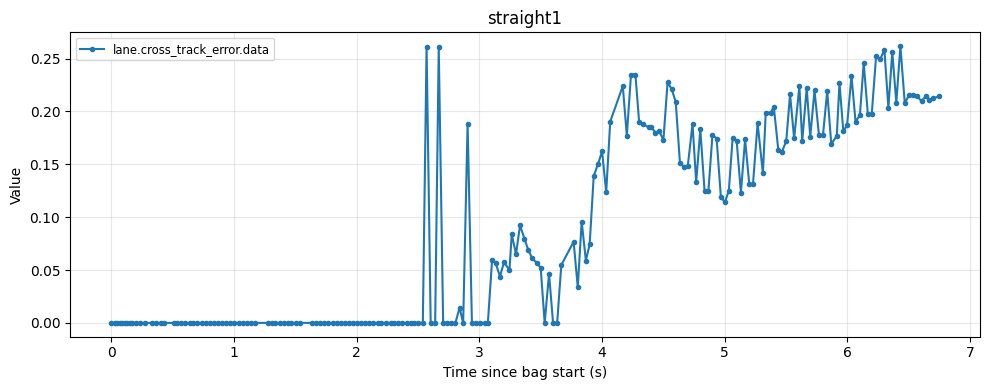

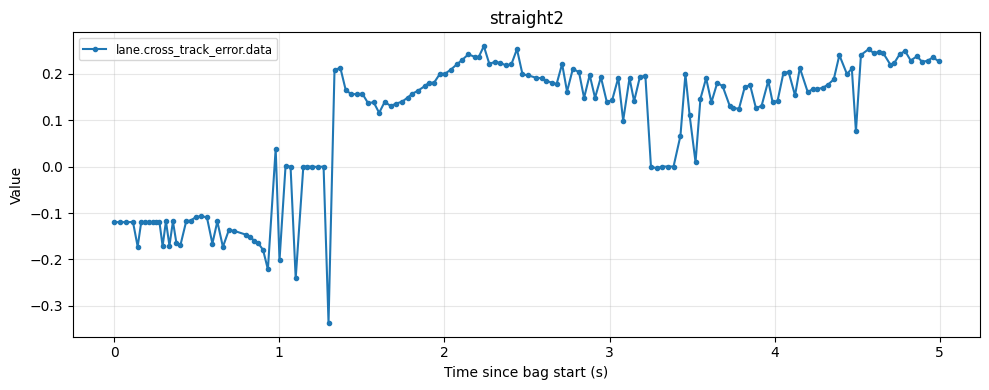

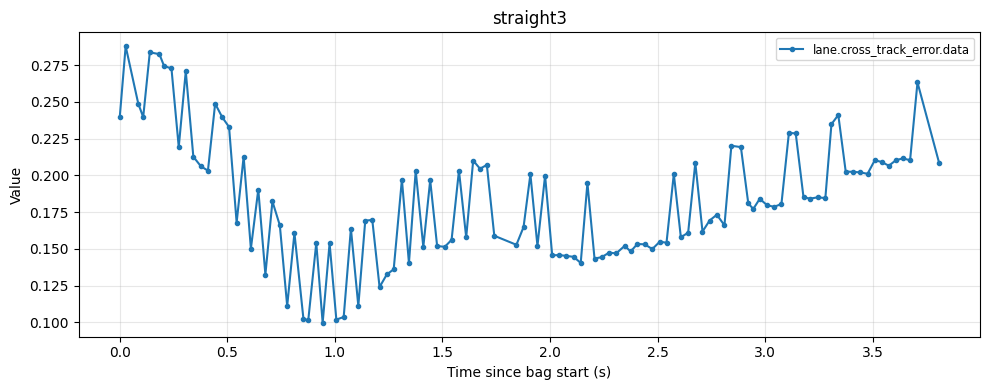

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

for name, df in dfs.items():
    # Normalize time to seconds since the bag's first message
    t = df["timestamp"] - df["timestamp"].min()

    # Every numeric column except timestamp is a data field worth plotting
    data_cols = [
        c for c in df.columns
        if c not in ("timestamp", "topic")
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in data_cols:
        mask = df[col].notna()           # rows from other topics will be NaN here
        ax.plot(t[mask], df[col][mask], marker=".", linestyle="-", label=col)

    ax.set_title(name)
    ax.set_xlabel("Time since bag start (s)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

CTE_COL = "lane.cross_track_error.data"


def time_window(df, t_start=None, t_end=None):
    """Filter df to rows where time-since-bag-start (in seconds) is in [t_start, t_end].
    Pass None for either side to leave that side open."""
    t = df["timestamp"] - df["timestamp"].min()
    mask = pd.Series(True, index=df.index)
    if t_start is not None:
        mask &= t >= t_start
    if t_end is not None:
        mask &= t <= t_end
    return df.loc[mask]


def average_cte(df, t_start=None, t_end=None, col=CTE_COL):
    """Mean cross-track error over [t_start, t_end] seconds since bag start."""
    return time_window(df, t_start, t_end)[col].mean()


def plot_bag(name, df, t_start=None, t_end=None):
    """Plot every numeric column vs. time, optionally truncated to a window."""
    t0 = df["timestamp"].min()
    sub = time_window(df, t_start, t_end)
    t = sub["timestamp"] - t0

    data_cols = [
        c for c in sub.columns
        if c not in ("timestamp", "topic")
        and pd.api.types.is_numeric_dtype(sub[c])
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in data_cols:
        mask = sub[col].notna()
        ax.plot(t[mask], sub[col][mask], marker=".", linestyle="-", label=col)

    title = name
    if t_start is not None or t_end is not None:
        lo = f"{t_start:.1f}" if t_start is not None else "0"
        hi = f"{t_end:.1f}" if t_end is not None else "end"
        title += f"  ({lo}s – {hi}s)"

    ax.set_title(title)
    ax.set_xlabel("Time since bag start (s)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()

curve1: avg CTE = 0.1280
curve2: avg CTE = 0.1128
curve3: avg CTE = 0.1861
straight1: avg CTE = 0.0898
straight2: avg CTE = 0.0898
straight3: avg CTE = 0.1831

Windowed (2s – 10s):
  curve1: avg CTE = 0.1239
  curve2: avg CTE = 0.1692
  curve3: avg CTE = 0.2303
  straight1: avg CTE = 0.1267
  straight2: avg CTE = 0.1776
  straight3: avg CTE = 0.1829


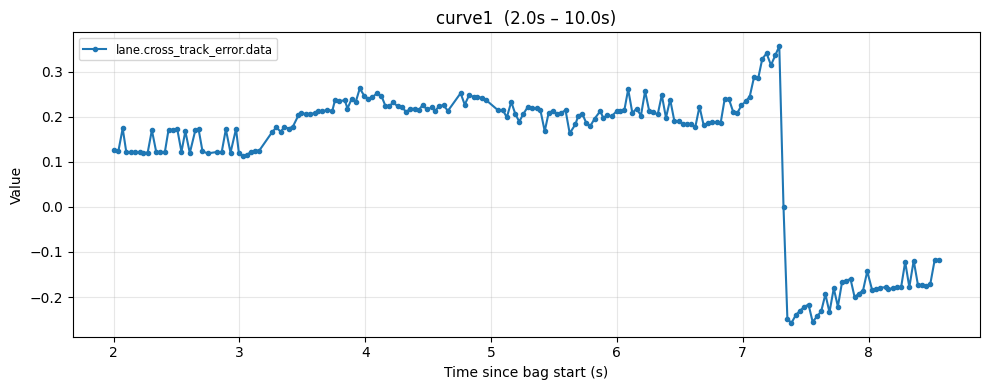

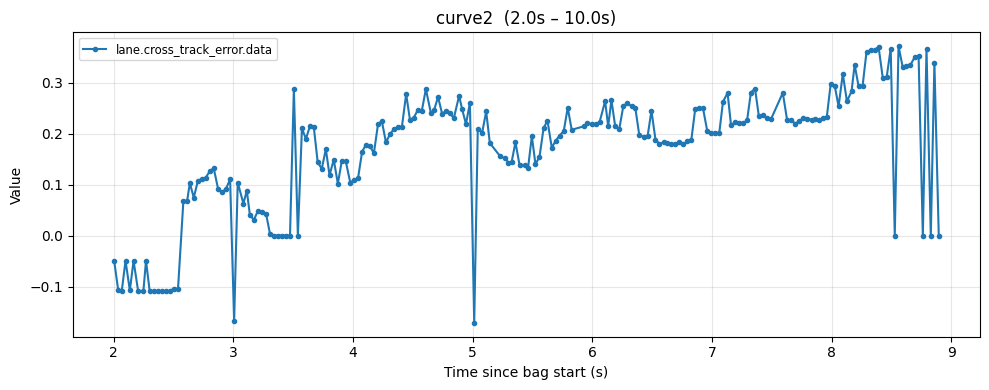

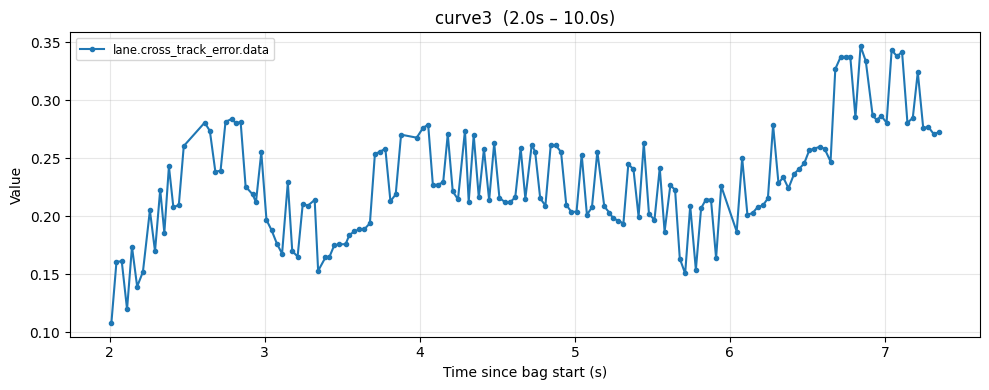

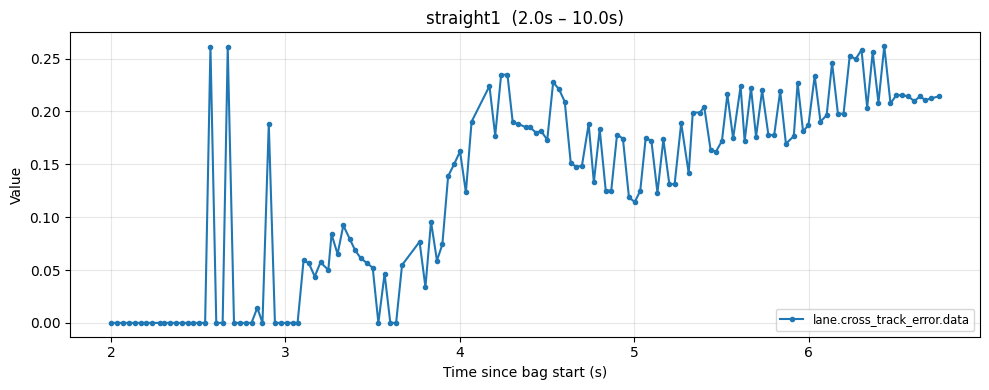

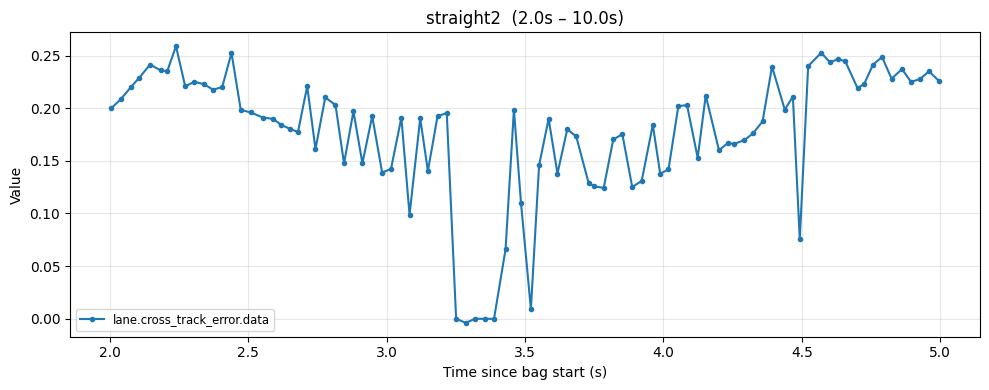

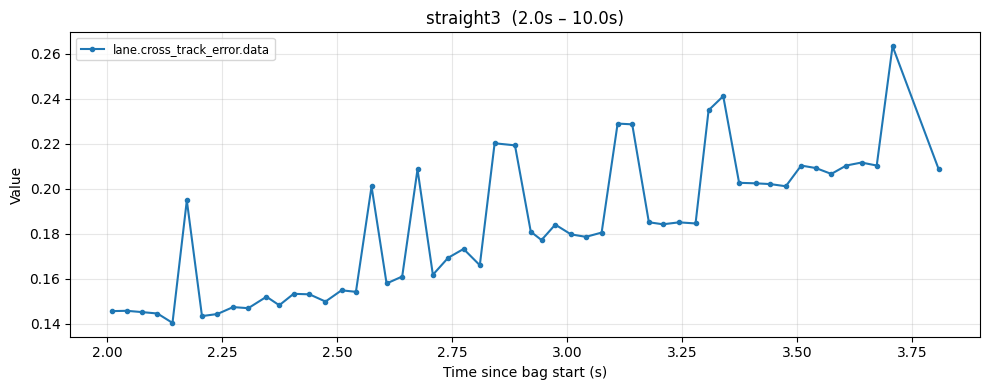

In [15]:
# Average CTE per bag, full window
for name, df in dfs.items():
    print(f"{name}: avg CTE = {average_cte(df):.4f}")

# Average CTE per bag, restricted to a window (e.g. 2s to 10s)
print("\nWindowed (2s – 10s):")
for name, df in dfs.items():
    print(f"  {name}: avg CTE = {average_cte(df, t_start=2, t_end=10):.4f}")

# Plots — pass t_start / t_end to truncate
for name, df in dfs.items():
    plot_bag(name, df, t_start=2, t_end=10)